# Project 3 — A News-Sentiment Factor with FinBERT

**Goal.** Turn financial news into a cross-sectional equity alpha factor: score every headline with **FinBERT** (a BERT model fine-tuned on
financial text), aggregate to stock-level daily sentiment, and test whether it predicts the cross-section of returns. Then back-test long–short
portfolios with costs, and check whether the "alpha" is just a known factor in disguise.

**Data (Massive).**
* ~750 000 news articles (Sep-2021 → Sep-2026) with publication timestamps, ticker tags, titles and descriptions
  (Zacks, GlobeNewswire, Motley Fool, Benzinga, MarketWatch, Seeking Alpha, …);
* the point-in-time **liquid-1500** universe (the 1 500 most liquid US stocks each month);
* daily split/dividend-adjusted returns and intraday spread estimates.

Earnings-call transcripts aren't in the data sets, so this study uses news only. The same pipeline applies to transcripts (score each paragraph,
aggregate per call, and measure the *change* versus the previous call).

| § | Content |
|---|---|
| 1 | From text to a factor: the pipeline and the look-ahead traps |
| 2 | FinBERT scoring (cached) and a lexicon baseline |
| 3 | A trap: headlines that *describe* past returns |
| 4 | Building the daily stock-level signal |
| 5 | Information coefficients and decay |
| 6 | Long–short portfolios, turnover and costs |
| 7 | Is it a new factor? Spanning regressions on market, reversal and momentum |
| 8 | Event study around strongly positive/negative news |
| 9 | Strengths, weaknesses, extensions |

## 1. The pipeline
1. **Score** each article: FinBERT outputs $P(\text{positive}),P(\text{negative}),P(\text{neutral})$; the article's tone is $s=P_{pos}-P_{neg}\in[-1,1]$.
2. **Assign** to stocks via the ticker tags; articles tagged with many tickers (market wrap-ups, lists) are down-weighted by 1/#tickers.
3. **Time-stamp correctly**: an article counts toward day $t$'s signal only if it was published before **15:30 ET** on $t$, so the portfolio can be traded
   in the closing auction. Anything later rolls into day $t+1$. Getting this wrong is the single most common source of fake alpha in news-sentiment studies.
4. **Aggregate** to a stock-day score, e.g. an exponentially-weighted average of recent tone, and *demean it by the stock's own history* (some firms always
   get cheerful press releases).
5. **Test** it cross-sectionally against *future* returns: close of $t$ to close of $t+h$.

In [1]:
import warnings, time, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from IPython.display import display

from qdata import load_news, load_panel, load_universe, CACHE, CURATED

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

## 2. FinBERT scores and a lexicon baseline
FinBERT (Araci 2019; `ProsusAI/finbert`) is BERT fine-tuned on the Financial PhraseBank. Scoring 750 k articles (title + first 400 characters of the
description, max 96 tokens) takes ~1–2 hours on a laptop GPU, so it's done once by `scripts/score_news_finbert.py`, which writes monthly shards
to `data_cache/finbert_news/`. The next cell loads the cached scores (or tells you to run the script).

As a baseline we build a deliberately simple **lexicon score**: (# positive words − # negative words) / (# words matched), with small hand-picked finance
word lists in the spirit of Loughran & McDonald (2011). If FinBERT can't beat a word count, the transformer isn't earning its compute.

In [2]:
shards = sorted((CACHE / "finbert_news").glob("*.parquet"))
if not shards:
    raise FileNotFoundError("Run `python scripts/score_news_finbert.py` first (writes data_cache/finbert_news/*.parquet).")
fb = pd.concat([pd.read_parquet(f) for f in shards], ignore_index=True).drop_duplicates("id")
news = load_news(columns=("id", "published_utc", "tickers", "title", "publisher.name"))
news = news.merge(fb, on="id", how="inner")
news["s_finbert"] = news.p_positive - news.p_negative

POS = set("beat beats beating raise raises raised upgrade upgraded upgrades record surge surges soar soars jump jumps strong strength growth "
          "outperform outperforms buy bullish gain gains profit profitable expand expands expansion win wins approval approved boost boosts "
          "exceed exceeds exceeded top tops rally rallies rebound improve improves improved positive optimistic".split())
NEG = set("miss misses missed cut cuts downgrade downgraded downgrades plunge plunges fall falls fell weak weakness loss losses decline declines "
          "sell bearish lawsuit probe investigation recall recalls drop drops slump slumps warn warns warning lower lowers lowered layoffs "
          "bankruptcy default fraud negative pessimistic tumble tumbles sink sinks slide slides".split())
tok = news.title.str.lower().str.findall(r"[a-z]+")
npos = tok.map(lambda w: sum(x in POS for x in w)); nneg = tok.map(lambda w: sum(x in NEG for x in w))
news["s_lexicon"] = ((npos - nneg) / (npos + nneg).replace(0, np.nan)).fillna(0.0)
print(f"{len(news):,} scored articles;  FinBERT label shares: "
      f"{(news[['p_positive','p_negative','p_neutral']].idxmax(1).value_counts(normalize=True)).round(3).to_dict()}")
print(f"corr(FinBERT tone, lexicon tone) = {news[['s_finbert','s_lexicon']].corr().iloc[0,1]:.2f}")
news.sort_values("s_finbert").iloc[[0, 1, 2, len(news) // 2, -3, -2, -1]][["title", "s_finbert", "s_lexicon"]]

750,589 scored articles;  FinBERT label shares: {'p_neutral': 0.474, 'p_positive': 0.332, 'p_negative': 0.194}
corr(FinBERT tone, lexicon tone) = 0.35


,title,s_finbert,s_lexicon
146599,Why Rocket Companies Shares Are Falling,-0.9701,0.0000
424908,Interim report - First half year of 2023 - SP ...,-0.9700,0.0000
477022,SP Group - Interim report - Third quarter of 2023,-0.9699,0.0000
526197,Akamai Technologies (AKAM) Q4 Earnings: Taking...,0.0815,0.0000
38179,Chemours (CC) Earnings and Revenues Surpass Es...,0.9493,0.0000
36713,Air Products (APD) Earnings and Revenues Surpa...,0.9493,0.0000
100589,Univar's (UNVR) Earnings and Revenues Top Esti...,0.9505,1.0000


## 3. A trap: headlines that describe past returns
Many headlines are **recaps of price moves**: "XYZ Stock Sinks As Market Gains", "ABC Soars 12% on…", "Why DEF Stock Plunged Today". Their tone is
positive exactly *because* the stock already went up. Their sentiment will correlate strongly with **same-day and past** returns, and it can look
predictive if timestamps are sloppy, or it can load on short-term *reversal* if they aren't. We flag them with a regex and measure how their sentiment
relates to the return on the publication day.

In [3]:
RECAP = re.compile(r"(stock moves|what you should know|gains as market|sinks as market|dips more than|outpaces stock market|lags market|"
                   r"\bsoar|\bplung|\bjump|\bsurg|\btumbl|\bslid|\bsink|\brall(y|ies)\b|\bdrop|\bdown \d|\bup \d|\d+(\.\d+)?%|"
                   r"why .* (stock|shares) (is|are|was|were) (up|down|higher|lower|falling|rising|soaring|sinking|plunging|jumping))",
                   re.IGNORECASE)
news["recap"] = news.title.str.contains(RECAP)
print(f"price-recap headlines: {news.recap.mean():.1%} of articles")

# ---- explode to (article, ticker) and time-stamp to a signal date --------------------------------------------------------
news["ts_ny"] = pd.to_datetime(news.published_utc, utc=True).dt.tz_convert("America/New_York").dt.tz_localize(None)
news["tick_list"] = news.tickers.str.findall(r'"([A-Z.\-]+)"')
news["n_tick"] = news.tick_list.str.len()
ex = news[news.n_tick.between(1, 10)].explode("tick_list").rename(columns={"tick_list": "ticker"})
ex["w"] = 1.0 / ex.n_tick

panel = load_panel(start="2021-09-01", end="2026-09-30", columns=("ticker", "ret", "close", "volume"))
sessions = pd.DatetimeIndex(sorted(panel.date.unique()))
cut = ex.ts_ny.dt.normalize() + pd.Timedelta(hours=15, minutes=30)
day = ex.ts_ny.dt.normalize().where(ex.ts_ny <= cut, ex.ts_ny.dt.normalize() + pd.Timedelta(days=1))
ex = ex[day.values <= sessions[-1]]
ex["date"] = sessions[np.searchsorted(sessions, day[day.values <= sessions[-1]].values)]     # next session on/after
ex = ex.merge(panel[["date", "ticker", "security_id"]], on=["date", "ticker"], how="inner")
print(f"{len(ex):,} (article, stock) pairs mapped to {ex.security_id.nunique():,} securities")

price-recap headlines: 14.5% of articles


1,456,471 (article, stock) pairs mapped to 11,955 securities


In [4]:
R = panel.pivot_table(index="date", columns="security_id", values="ret").sort_index()
lr = np.log1p(R.clip(lower=-0.95))
same = lr.stack().rename("r0")
prev = lr.shift(1).stack().rename("r_prev")
nxt = lr.shift(-1).stack().rename("r_next")
art = ex.join(same, on=["date", "security_id"]).join(prev, on=["date", "security_id"]).join(nxt, on=["date", "security_id"])
rows = []
for lab, g in [("price-recap headlines", art[art.recap]), ("other headlines", art[~art.recap])]:
    rows.append({"articles": len(g), "corr(tone, previous-day return)": g[["s_finbert", "r_prev"]].corr().iloc[0, 1],
                 "corr(tone, same-day return)": g[["s_finbert", "r0"]].corr().iloc[0, 1],
                 "corr(tone, next-day return)": g[["s_finbert", "r_next"]].corr().iloc[0, 1]})
pd.DataFrame(rows, index=["price-recap headlines", "other headlines"])

,articles,"corr(tone, previous-day return)","corr(tone, same-day return)","corr(tone, next-day return)"
price-recap headlines,188860,0.1154,0.0743,0.0104
other headlines,1267611,0.0343,0.0528,0.0047


Recap headlines' tone is strongly correlated with the return on the day they're published (or the day before, for overnight recaps). They *describe*
returns and carry little new information about the future. We therefore build the main signal **without** recap headlines, and show the
difference later.

## 4. The daily stock-level signal
For stock $i$ on day $t$ (news up to 15:30 ET):
$$\text{tone}_{i,t}=\frac{\sum_{a\in t}w_a s_a}{\sum_{a\in t}w_a},\qquad
\text{SENT}_{i,t}=\text{EWMA}_{hl=5}(\text{tone}_{i,\cdot})_t-\text{mean}_{252}(\text{tone}_{i,\cdot})_{t-1}$$
i.e. recent tone (half-life 5 news days, carried forward between news) relative to the stock's own one-year average tone. Stocks with no news in the last
21 sessions get no score. Each day we rank scores **within the point-in-time liquid-1500 universe**.

In [5]:
univ = load_universe("liquid_1500")[["date", "security_id"]]
univ_set = set(zip(univ.date.values, univ.security_id.values))
dates = R.index


def build_signal(col, use_recap=False, hl=5, fresh_only=False):
    a = art if use_recap else art[~art.recap]
    daily = (a.assign(ws=a[col] * a.w).groupby(["date", "security_id"])[["ws", "w"]].sum())
    tone = (daily.ws / daily.w).unstack().reindex(dates)
    cnt = daily.w.unstack().reindex(dates).notna()
    recent = tone.ewm(halflife=hl, ignore_na=True).mean()                  # carried forward between news days
    base = tone.rolling(252, min_periods=20).mean().shift(1).ffill()
    if fresh_only:                                    # event-driven: only stocks with news *today*, today's tone vs own baseline
        return (tone - base.fillna(0.0)).where(cnt)
    live = cnt.rolling(21, min_periods=1).sum() > 0
    sig = (recent - base.fillna(0.0)).where(live)
    return sig


t0 = time.time()
SIG = {"FinBERT (ex-recaps)": build_signal("s_finbert"), "FinBERT (all headlines)": build_signal("s_finbert", use_recap=True),
       "Lexicon (ex-recaps)": build_signal("s_lexicon"),
       "FinBERT news-day only (ex-recaps)": build_signal("s_finbert", fresh_only=True)}
# restrict to the point-in-time universe
um = univ.assign(v=1).pivot_table(index="date", columns="security_id", values="v").reindex(dates).ffill(limit=25)
for k in SIG:
    SIG[k] = SIG[k].reindex(columns=R.columns).where(um.reindex(columns=R.columns).notna())
cov = SIG["FinBERT (ex-recaps)"].notna().sum(1); cov2 = SIG["FinBERT news-day only (ex-recaps)"].notna().sum(1)
print(f"signals built in {time.time()-t0:.0f}s; median stocks with a score per day: {cov[cov > 0].median():.0f} of ~1 500 "
      f"(news-day-only signal: {cov2[cov2 > 0].median():.0f})")

signals built in 3s; median stocks with a score per day: 1423 of ~1 500 (news-day-only signal: 390)


## 5. Information coefficients
The IC is the daily cross-sectional **Spearman rank correlation** between the signal at the close of $t$ and the return from close $t$ to close $t+h$. We report
its mean, its t-statistic (Newey–West, $h$ lags, since $h$-day returns overlap) and the IC information ratio. A mean IC of 0.01–0.02 is typical of a *useful*
daily equity signal.

In [6]:
def fwd_ret(h):
    return np.expm1(lr.rolling(h).sum().shift(-h))


FWD = {h: fwd_ret(h) for h in [1, 5, 21]}
FWD_skip = np.expm1(lr.rolling(5).sum().shift(-6))        # skip one day: days t+2..t+6


def daily_ic(sig, fwd):
    s, f = sig.rank(axis=1, pct=True), fwd.rank(axis=1, pct=True)
    ok = s.notna() & f.notna()
    s, f = s.where(ok), f.where(ok)
    sm_ = s.sub(s.mean(1), axis=0); fm = f.sub(f.mean(1), axis=0)
    ic = (sm_ * fm).sum(1) / np.sqrt((sm_ ** 2).sum(1) * (fm ** 2).sum(1))
    return ic[ok.sum(1) >= 50]


def nw_t(x, lags):
    r = sm.OLS(x.values, np.ones(len(x))).fit(cov_type="HAC", cov_kwds={"maxlags": lags})
    return r.tvalues[0]


rows = []
ICS = {}
for name, sig in SIG.items():
    for h, fw in list(FWD.items()) + [("5 (skip 1d)", FWD_skip)]:
        ic = daily_ic(sig, fw); ICS[(name, h)] = ic
        lags = 6 if h == "5 (skip 1d)" else h
        rows.append({"signal": name, "horizon (days)": h, "mean IC": ic.mean(), "NW t-stat": nw_t(ic, lags),
                     "IC IR (ann.)": ic.mean() / ic.std() * np.sqrt(252 / (5 if h == "5 (skip 1d)" else h)), "% days IC>0": (ic > 0).mean()})
ic_tab = pd.DataFrame(rows).set_index(["signal", "horizon (days)"])
ic_tab

mean IC  NW t-stat  \
signal                            horizon (days)                       
FinBERT (ex-recaps)               1                0.0004     0.2551   
                                  5               -0.0026    -0.9164   
                                  21              -0.0081    -1.5331   
                                  5 (skip 1d)     -0.0027    -0.9250   
FinBERT (all headlines)           1                0.0005     0.3316   
                                  5               -0.0032    -1.1049   
                                  21              -0.0094    -1.8289   
                                  5 (skip 1d)     -0.0031    -1.0574   
Lexicon (ex-recaps)               1               -0.0005    -0.3918   
                                  5               -0.0033    -1.3989   
                                  21              -0.0059    -1.4831   
                                  5 (skip 1d)     -0.0040    -1.6899   
FinBERT news-day only (ex-recaps) 1                0.0029     1.2506   
                                  5                0.0005     0.1766   
                                  21              -0.0039    -1.1014   
                                  5 (skip 1d)     -0.0003    -0.1306   

                                                  IC IR (ann.)  % days IC>0  
signal                            horizon (days)                             
FinBERT (ex-recaps)               1                     0.1171       0.5034  
                                  5                    -0.3422       0.4932  
                                  21                   -0.5482       0.4377  
                                  5 (skip 1d)          -0.3505       0.4893  
FinBERT (all headlines)           1                     0.1507       0.5068  
                                  5                    -0.4111       0.4753  
                                  21                   -0.6599       0.4170  
                                  5 (skip 1d)          -0.3981       0.4680  
Lexicon (ex-recaps)               1                    -0.1800       0.4906  
                                  5                    -0.5233       0.4761  
                                  21                   -0.5081       0.4576  
                                  5 (skip 1d)          -0.6476       0.4705  
FinBERT news-day only (ex-recaps) 1                     0.5632       0.5248  
                                  5                     0.0416       0.5094  
                                  21                   -0.1705       0.4730  
                                  5 (skip 1d)          -0.0299       0.5021

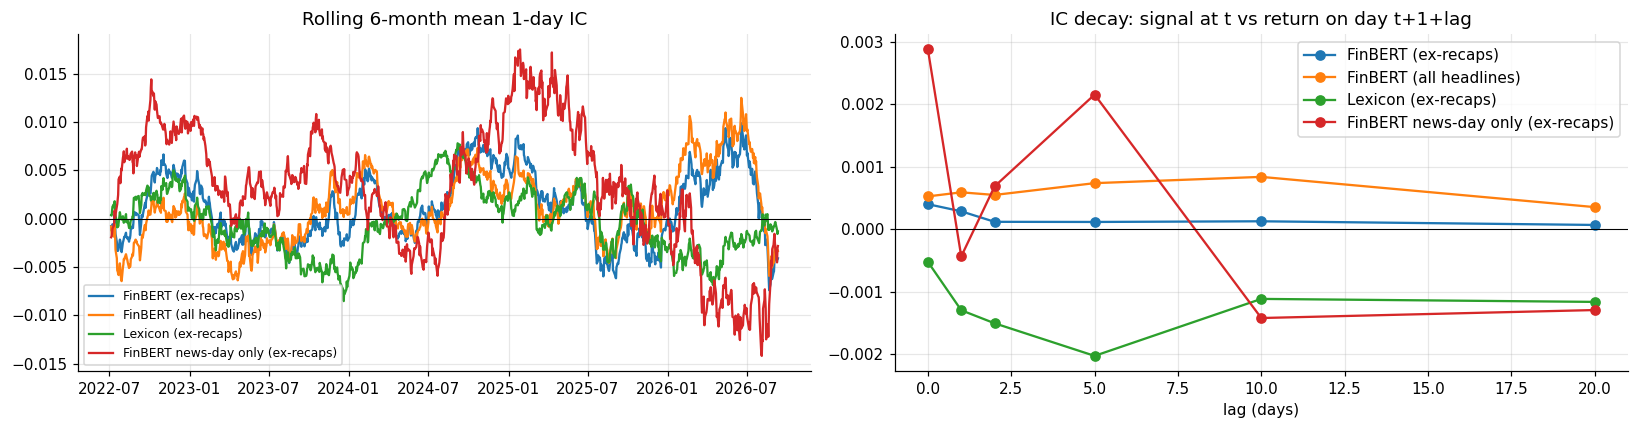

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(15, 4))
for name in SIG:
    axs[0].plot(ICS[(name, 1)].rolling(126).mean(), label=name)
axs[0].axhline(0, color="k", lw=.7); axs[0].set_title("Rolling 6-month mean 1-day IC"); axs[0].legend(fontsize=8)
decay = []
for lag in [0, 1, 2, 5, 10, 20]:
    fw = np.expm1(lr.shift(-1 - lag))                       # return on day t+1+lag
    decay.append({"lag": lag, **{n: daily_ic(SIG[n], fw).mean() for n in SIG}})
pd.DataFrame(decay).set_index("lag").plot(ax=axs[1], marker="o")
axs[1].axhline(0, color="k", lw=.7); axs[1].set_title("IC decay: signal at t vs return on day t+1+lag"); axs[1].set_xlabel("lag (days)")
plt.tight_layout(); plt.show()

## 6. Long–short portfolios
Each day: long the top quintile of sentiment, short the bottom quintile, equal-weighted, **held for 5 days** (1/5 of the book rebalanced daily, the
standard overlapping-portfolio construction), which cuts turnover relative to daily rebalancing. Costs: each stock's estimated half-spread (Massive intraday
`spread_est`, previous day) per unit traded. We report gross and net performance.

ann. return  ann. vol  \
FinBERT (ex-recaps)               gross                    -0.0294    0.0726   
                                  net of half-spreads      -0.0434    0.0725   
FinBERT (all headlines)           gross                    -0.0355    0.0725   
                                  net of half-spreads      -0.0499    0.0725   
Lexicon (ex-recaps)               gross                    -0.0059    0.0600   
                                  net of half-spreads      -0.0201    0.0599   
FinBERT news-day only (ex-recaps) gross                    -0.0283    0.0684   
                                  net of half-spreads      -0.0722    0.0684   

                                                       Sharpe  max DD  \
FinBERT (ex-recaps)               gross               -0.4057 -0.1942   
                                  net of half-spreads -0.5977 -0.2350   
FinBERT (all headlines)           gross               -0.4897 -0.2321   
                                  net of half-spreads -0.6889 -0.2701   
Lexicon (ex-recaps)               gross               -0.0977 -0.1274   
                                  net of half-spreads -0.3346 -0.1543   
FinBERT news-day only (ex-recaps) gross               -0.4141 -0.2299   
                                  net of half-spreads -1.0561 -0.3162   

                                                       daily turnover  
FinBERT (ex-recaps)               gross                        0.1925  
                                  net of half-spreads          0.1925  
FinBERT (all headlines)           gross                        0.1973  
                                  net of half-spreads          0.1973  
Lexicon (ex-recaps)               gross                        0.2003  
                                  net of half-spreads          0.2003  
FinBERT news-day only (ex-recaps) gross                        0.6682  
                                  net of half-spreads          0.6682

Event-driven variant:


,ann. return,ann. vol,Sharpe,max DD,daily turnover
gross,-0.0079,0.0611,-0.1288,-0.1197,0.1773
net of half-spreads,-0.0201,0.0610,-0.3286,-0.1278,0.1773


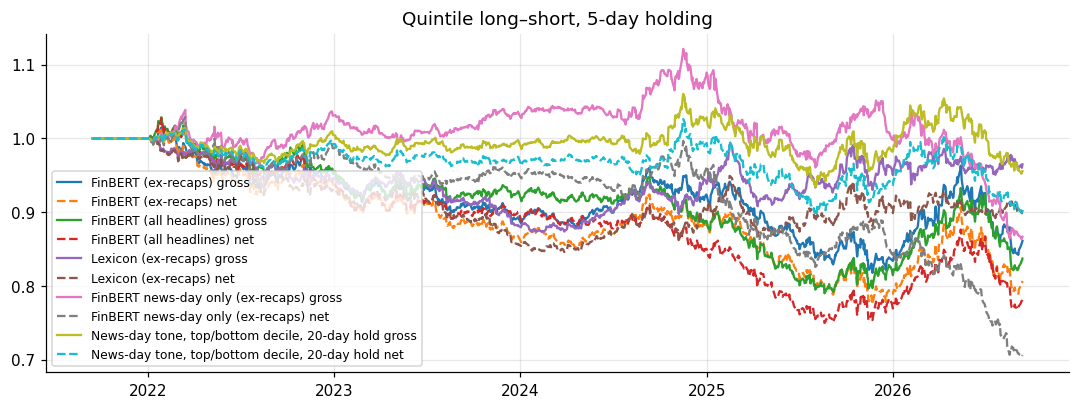

In [8]:
feat_files = sorted((CURATED / "intraday").glob("year=*/*.parquet"))
sp_parts = []
for f in feat_files:
    d = pd.read_parquet(f, columns=["security_id", "spread_est", "date"])
    sp_parts.append(d)
SPR = pd.concat(sp_parts); SPR["date"] = pd.to_datetime(SPR.date)
SPR = SPR.pivot_table(index="date", columns="security_id", values="spread_est").reindex(index=dates, columns=R.columns)
half_spread = (SPR.shift(1) / 2).clip(upper=0.02).fillna(0.002)


def ls_backtest(sig, hold=5, q=0.2):
    rk = sig.rank(axis=1, pct=True)
    n_ok = sig.notna().sum(1)
    long = (rk >= 1 - q).astype(float); short = (rk <= q).astype(float)
    long = long.div(long.sum(1).replace(0, np.nan), axis=0); short = short.div(short.sum(1).replace(0, np.nan), axis=0)
    w_day = (long - short).where(n_ok >= 50, 0.0).fillna(0.0)
    W = w_day.rolling(hold, min_periods=1).mean()                     # overlapping 5-day cohorts
    gross = (W.shift(1) * R.fillna(0)).sum(1)
    turn = W.diff().abs().sum(1)
    cost = (W.diff().abs() * half_spread).sum(1)
    return gross, gross - cost, turn, W


def perf(r):
    r = r.loc[r.ne(0).idxmax():]
    ann = r.mean() * 252; vol = r.std() * np.sqrt(252); eq = (1 + r).cumprod()
    return {"ann. return": ann, "ann. vol": vol, "Sharpe": ann / vol, "max DD": (eq / eq.cummax() - 1).min()}


BT = {n: ls_backtest(s) for n, s in SIG.items()}
tab = {}
for n, (g, nt, turn, _) in BT.items():
    tab[(n, "gross")] = perf(g); tab[(n, "net of half-spreads")] = perf(nt)
    tab[(n, "gross")]["daily turnover"] = turn.mean(); tab[(n, "net of half-spreads")]["daily turnover"] = turn.mean()
display(pd.DataFrame(tab).T)

# event-driven variant: each day go long the top-decile / short the bottom-decile news-day tone, hold each cohort 20 days
BT["News-day tone, top/bottom decile, 20-day hold"] = ls_backtest(SIG["FinBERT news-day only (ex-recaps)"], hold=20, q=0.1)
g, nt, turn, _ = BT["News-day tone, top/bottom decile, 20-day hold"]
tab2 = pd.DataFrame({"gross": perf(g), "net of half-spreads": perf(nt)}).T.assign(**{"daily turnover": turn.mean()})
print("Event-driven variant:"); display(tab2)

fig, ax = plt.subplots(figsize=(12, 4))
for n, (g, nt, _, _) in BT.items():
    ax.plot((1 + g).cumprod(), label=f"{n} gross"); ax.plot((1 + nt).cumprod(), ls="--", label=f"{n} net")
ax.set_title("Quintile long–short, 5-day holding"); ax.legend(fontsize=8); plt.show()

## 7. Is it a new factor?
Sentiment is mechanically related to recent returns (good news follows price rises), so a sentiment long–short could simply be a disguised **short-term reversal**
(short last week's winners) or **momentum** bet. We build those factors from the same universe and regress the sentiment portfolio's daily returns on them:
* **MKT**: equal-weighted universe return;
* **STR**: short-term reversal, long the bottom / short the top quintile of the past-5-day return;
* **MOM**: momentum, long the top / short the bottom quintile of the 12-1 month return.

In [9]:
in_u = um.reindex(columns=R.columns).notna()
mkt = R.where(in_u).mean(1)
past5 = lr.rolling(5).sum().where(in_u)
mom = lr.shift(21).rolling(231).sum().where(in_u)
str_g, _, _, _ = ls_backtest(-past5, hold=5)
mom_g, _, _, _ = ls_backtest(mom, hold=21)
F = pd.DataFrame({"MKT": mkt, "STR": str_g, "MOM": mom_g}).dropna()
rows = {}
for n, (g, _, _, _) in BT.items():
    y = g.reindex(F.index)
    X = sm.add_constant(F)
    r = sm.OLS(y, X, missing="drop").fit(cov_type="HAC", cov_kwds={"maxlags": 5})
    rows[n] = {"alpha (ann.)": r.params["const"] * 252, "alpha t": r.tvalues["const"], "β MKT": r.params["MKT"],
               "β STR": r.params["STR"], "t STR": r.tvalues["STR"], "β MOM": r.params["MOM"], "t MOM": r.tvalues["MOM"], "R²": r.rsquared}
pd.DataFrame(rows).T

,alpha (ann.),alpha t,β MKT,β STR,t STR,β MOM,t MOM,R²
FinBERT (ex-recaps),-0.0443,-1.5860,0.0164,-0.0430,-2.4790,0.1770,9.4880,0.2895
FinBERT (all headlines),-0.0434,-1.5991,-0.0040,-0.0689,-3.5379,0.1599,8.4898,0.2613
Lexicon (ex-recaps),-0.0141,-0.5182,-0.0008,-0.0112,-0.7157,0.0909,5.8964,0.1108
FinBERT news-day only (ex-recaps),-0.0117,-0.4345,-0.0451,-0.1197,-7.1586,0.0271,1.8209,0.1462
"News-day tone, top/bottom decile, 20-day hold",-0.0072,-0.2795,0.0041,-0.0511,-3.4214,0.0526,3.2101,0.0541


## 8. Event study: returns around strongly positive and negative news
Take stock-days whose FinBERT day-tone (non-recap articles) is in the top or bottom 5 % of all news days, and average the cumulative *market-adjusted*
return from 10 days before to 20 days after. This shows **when** the information gets into prices: before the news (leakage, or the news is a
reaction), on the day, or afterwards (drift, which is what a factor can harvest).

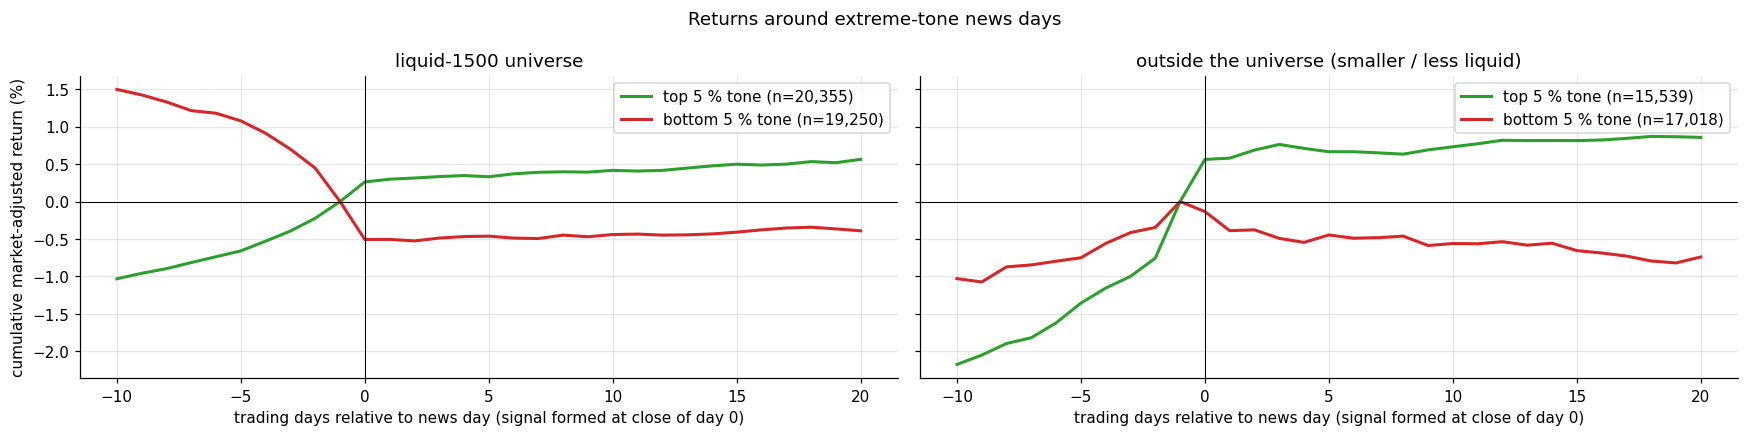

events  \
liquid-1500 universe                         top 5 % tone    20,355.0000   
                                             bottom 5 % tone 19,250.0000   
outside the universe (smaller / less liquid) top 5 % tone    15,539.0000   
                                             bottom 5 % tone 17,018.0000   

                                                              CAR day −10→−1 (%)  \
liquid-1500 universe                         top 5 % tone                 1.0313   
                                             bottom 5 % tone             -1.4976   
outside the universe (smaller / less liquid) top 5 % tone                 2.1751   
                                             bottom 5 % tone              1.0291   

                                                              day-0 return (%)  \
liquid-1500 universe                         top 5 % tone               0.2623   
                                             bottom 5 % tone           -0.5066   
outside the universe (smaller / less liquid) top 5 % tone               0.5628   
                                             bottom 5 % tone           -0.1335   

                                                              post-news drift day 0→20 (%)  
liquid-1500 universe                         top 5 % tone                           0.3018  
                                             bottom 5 % tone                        0.1158  
outside the universe (smaller / less liquid) top 5 % tone                           0.2942  
                                             bottom 5 % tone                       -0.6063

In [10]:
a = art[~art.recap]
dtone = (a.assign(ws=a.s_finbert * a.w).groupby(["date", "security_id"])[["ws", "w"]].sum())
dtone = (dtone.ws / dtone.w).rename("tone").reset_index()
lo, hi = dtone.tone.quantile([0.05, 0.95])
ar = R.sub(mkt, axis=0)                                  # market-adjusted daily returns
arv = ar.values; didx = {d: i for i, d in enumerate(dates)}; cidx = {c: j for j, c in enumerate(R.columns)}
win = np.arange(-10, 21)


def car(events):
    out = []
    for d, s in zip(events.date, events.security_id):
        i, j = didx.get(d), cidx.get(s)
        if i is None or j is None or i + win[0] < 0 or i + win[-1] >= len(dates):
            continue
        out.append(np.nan_to_num(arv[i + win, j]))
    out = np.array(out)
    c = out.cumsum(1)
    return c - c[:, [9]], len(out)                        # normalise to 0 at t = -1


dtone["in_universe"] = [(d, sid) in univ_set for d, sid in zip(dtone.date.values, dtone.security_id.values)]
fig, axs = plt.subplots(1, 2, figsize=(16, 4), sharey=True)
drift = {}
for ax, (ulab, sub) in zip(axs, [("liquid-1500 universe", dtone[dtone.in_universe]), ("outside the universe (smaller / less liquid)", dtone[~dtone.in_universe])]):
    for lab, evs, col in [("top 5 % tone", sub[sub.tone >= hi], "tab:green"), ("bottom 5 % tone", sub[sub.tone <= lo], "tab:red")]:
        c, n = car(evs.sample(min(len(evs), 30_000), random_state=0))
        m_ = c.mean(0) * 100
        drift[(ulab, lab)] = {"events": n, "CAR day −10→−1 (%)": -m_[0], "day-0 return (%)": m_[10],
                              "post-news drift day 0→20 (%)": m_[-1] - m_[10]}
        ax.plot(win, m_, color=col, lw=2, label=f"{lab} (n={n:,})")
    ax.axvline(0, color="k", lw=.7); ax.axhline(0, color="k", lw=.7); ax.set_title(ulab); ax.legend()
    ax.set_xlabel("trading days relative to news day (signal formed at close of day 0)")
axs[0].set_ylabel("cumulative market-adjusted return (%)")
plt.suptitle("Returns around extreme-tone news days"); plt.tight_layout(); plt.show()
pd.DataFrame(drift).T

## 9. Interpretation, strengths, weaknesses
**What the evidence says.** This is a *negative result*, and an instructive one:
* **No reliable predictive power in liquid stocks.** Every IC is statistically indistinguishable from zero. The best is the news-day-only signal at a 1-day
  horizon (mean IC ≈ 0.003, t ≈ 1.3). The carried-forward signals even turn slightly *negative* at 21 days. Every long–short variant loses money before
  costs, and more after them.
* **News follows prices.** The event study shows a large **pre-news** move: liquid stocks with very positive news days had already risen ~1 % over the
  previous two weeks, and those with very negative news had fallen ~1.5 %. Much of "sentiment" is the press describing what the market already priced.
* **So sentiment is a disguised momentum/reversal bet.** The carried-forward sentiment portfolio loads heavily on **momentum** (t ≈ 9) and the news-day
  portfolio on **short-term reversal** (long recent winners, t ≈ −7 on STR). Once those exposures are controlled for, alpha is insignificant.
* **Where sentiment does work: outside the liquid universe.** For smaller, less liquid stocks, bad news keeps drifting down (≈ −0.6 % over the next 20 days),
  while inside the liquid-1500 the post-news drift is small and not even symmetric. That matches the literature (Tetlock 2007; Chan 2003; Ke–Kelly–Xiu 2019):
  underreaction to news, especially bad news, is concentrated where arbitrage is costly (short-sale constraints, wide spreads, low attention). That's also where
  a real strategy would struggle to make money after costs.
* **Recap headlines** make things slightly worse (more reversal loading), as §3 predicted. **FinBERT vs lexicon**: the transformer is far better at *reading*
  headlines (see the example rankings in §2, where the lexicon misses most of them), but better reading doesn't create information the market hasn't already
  priced.

**How to make a news signal work** (what practitioners actually do): react **intraday** within seconds or minutes of publication, not at the close; focus on
**novel** stories (not the 10th article about the same event); weight by **surprise** (earnings vs consensus, guidance changes) rather than tone; and target
stocks where news is rarer and attention lower.

**Strengths**
* A realistic, point-in-time pipeline: publication timestamps with a 15:30 cut-off, point-in-time universe, adjusted returns, overlapping-portfolio construction,
  and spread-based costs.
* FinBERT gives a domain-adapted, context-aware tone for every headline, with no hand-labelling.
* The spanning regression and event study separate genuine new information from repackaged price information.

**Weaknesses**
* **Headlines + short descriptions only**, no full text or transcripts. Coverage is skewed toward large caps and press-release-heavy firms.
* **Vendor timestamps** can lag the real first publication (e.g. a newswire), and articles can be revised. Real-time feeds with microsecond stamps are
  what professional news-trading uses.
* FinBERT was trained on a small labelled corpus (Financial PhraseBank) of sentences unlike today's clickbait headlines. It doesn't know which company the
  sentence is *about* in multi-ticker articles.
* Only 5 years of data, so few independent market regimes.

**Extensions**
* Entity-level (aspect-based) sentiment for multi-ticker articles; LLM-based scoring (e.g. with Claude) with prompts that ask for *surprise relative to
  expectations* rather than tone.
* Novelty filters: drop articles similar to earlier ones (embedding similarity), since only new information moves prices.
* Earnings-call transcripts: change in management tone between consecutive calls, and Q&A vs prepared remarks.
* Combine with the Massive `short_interest` and `short_volume` data: negative news on heavily shorted stocks.

**References.** Tetlock, "Giving content to investor sentiment", *J. Finance* (2007); Loughran & McDonald, "When is a liability not a liability?", *J. Finance*
(2011); Araci, "FinBERT" (2019); Ke, Kelly & Xiu, "Predicting returns with text data" (2019); Huang, Wang & Yang, "FinBERT: a large language model for
extracting information from financial text", *CAR* (2023).